# **Project 1: The Evolution Simulator**

# The Tech Stack
*   numpy - for complex maths calculations and matrices manipulation.
*   matplotlib and searborn for visualisations .



---


# The Rules of Life
The simulation follows four simple rules for every cell in a 2D grid:

Birth: A dead cell with exactly 3 neighbors becomes alive.

Survival: A live cell with 2 or 3 neighbors stays alive.

Death (Overpopulation): A live cell with >3 neighbors dies.

Death (Isolation): A live cell with <2 neighbors dies.

In [ ]:
#importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [ ]:
class EvolutionSimulator:
    def __init__(self, size=50, density=0.2):
        self.size = size
        # Create a random grid of 0s (dead) and 1s (alive)
        self.grid = np.random.choice([0, 1], size=(size, size), p=[1-density, density])
        #here 1-density is the probability of choosing 0 a dead cell and density is the probability of chooding 1 a living cell if density is .2 then 20 chance is that cell is living or satart live but if .8 then it start as dead .
        # thus p = [.8,.2]

    def update(self, frameNum, img, grid, size):
        # We make a copy of the grid to apply rules without changing the original during the check
        new_grid = grid.copy()

        for i in range(size):
            for j in range(size):
                # Compute the sum of the 8 neighbors (using modulo % for wrap-around "toroidal" world)
                total = int((grid[i, (j-1)%size] + grid[i, (j+1)%size] +
                             grid[(i-1)%size, j] + grid[(i+1)%size, j] +
                             grid[(i-1)%size, (j-1)%size] + grid[(i-1)%size, (j+1)%size] +
                             grid[(i+1)%size, (j-1)%size] + grid[(i+1)%size, (j+1)%size]))

                # Apply Conway's Rules
                if grid[i, j] == 1:
                    if (total < 2) or (total > 3):
                        new_grid[i, j] = 0
                else:
                    if total == 3:
                        new_grid[i, j] = 1

        # Update the visual data
        img.set_data(new_grid)
        grid[:] = new_grid[:]
        return img,


In [ ]:
# --- SETUP THE ANIMATION ---
size = 50
sim = EvolutionSimulator(size=size, density=0.18)

fig, ax = plt.subplots(figsize=(8, 8))
img = ax.imshow(sim.grid, interpolation='nearest', cmap='viridis')
ani = animation.FuncAnimation(fig, sim.update, fargs=(img, sim.grid, size),
                              frames=50, interval=100, save_count=50)

plt.close() # Prevents extra static plot from showing
HTML(ani.to_jshtml())

/tmp/ipykernel_2760/3340690498.py:7: UserWarning: You passed in an explicit save_count=50 which is being ignored in favor of frames=50.
  ani = animation.FuncAnimation(fig, sim.update, fargs=(img, sim.grid, size),


In [ ]:
# https://en.wikipedia.org/wiki/Conway%27s_Game_of_Life

# **Project 2: The AI Ghost-Writer**

1. The Tech Stack
Collections (Counter/Defaultdict): These are advanced Python data structures that make counting word patterns much faster than a standard dictionary.

Random: Used to pick the "next" word based on the patterns the AI learned.

Strings & Regex: To clean the text (removing punctuation and making it lowercase).

2. The Concept: N-Grams
The "brain" of this project is based on Bigrams. If your AI reads the sentence "The cat sat on the mat," it learns:

After "The" comes "cat"

After "cat" comes "sat"

After "sat" comes "on"

In [ ]:
import random
from collections import defaultdict

class GhostWriter:

  def __init__(self):
    self.model = defaultdict(list)

  def train(self,data):
    words = data.split()

    for i in range(len(words) - 1):
      current_word = words[i].lower().strip()
      next_word = words[i+1].lower().strip()
      self.model[current_word].append(next_word)
    print(f"✅ Training complete! Learned {len(self.model)} unique word patterns.")

  def generator(self,start_word,length=30):
    current = start_word.lower()
    output = [current]

    for _ in range(length):
            # Find all possible words that could follow the current one
            possibilities = self.model.get(current)
            if not possibilities:
                break

            # Pick one randomly
            next_word = random.choice(possibilities)
            output.append(next_word)
            current = next_word

    return " ".join(output) + "..."

# --- LET'S TRAIN IT ---
# You can paste a huge block of text here (like a news article or a poem)
sample_text = """
Python is an amazing language for beginners and experts alike.
Python allows you to build projects that are effective and professional.
I love to build things with Python because Python makes coding fun.
Coding is the path to becoming a professional developer.
"""

ai = GhostWriter()
ai.train(sample_text)

# --- GENERATE NEW TEXT ---
print("\n--- AI GENERATED TEXT ---")
print(ai.generator("python", length=15))


✅ Training complete! Learned 32 unique word patterns.

--- AI GENERATED TEXT ---
python makes coding is the path to build projects that are effective and experts alike. python...


# Project-3 qr code generator

## Project 3: QR Code Generator

This project demonstrates how to generate QR codes using Python libraries. It covers:

*   **qrcode**: A library for creating QR codes.
*   **segno**: Another powerful library for generating QR codes, used here for styled images.
*   **StyledPilImage**: Used for customizing the appearance of QR codes, including embedding logos.

The core concept is to take input text or URLs and convert them into scannable QR codes, with options for styling and adding custom images (like logos) within the QR code itself.

In [ ]:
!pip install qrcode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 623.6 kB/s eta 0:00:00


In [ ]:
!pip install segno

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 930.0 kB/s eta 0:00:00


In [ ]:
import qrcode
from qrcode.image.styledpil import StyledPilImage
from qrcode.image.styles.moduledrawers import RoundedModuleDrawer
import segno

In [ ]:
import qrcode
from qrcode.image.styledpil import StyledPilImage

class QRCodeGenerator:

  def __init__(self ,text='no-text', logo_path=None ,img_url=None):
     self.text = text
     self.logo_path = logo_path
     self.img_url = img_url

  def generate(self):
    qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=10,
    border=4,
    )
    qr.add_data(self.text)
    qr.make(fit=True)

    if self.logo_path:
        # Use StyledPilImage with logo_path for embedding logo
        img = qr.make_image(image_factory=StyledPilImage,
                            embeded_image_path=self.logo_path,
                            module_drawer=RoundedModuleDrawer())
    else:
        # Original behavior without logo
        img = qr.make_image(back_color=(0, 0, 130), fill_color=(225,225,225 ))

    return img

  def save(self,path):
    img = self.generate()
    img.save(path)




In [ ]:
TARGET_IMAGE = "https://upload.wikimedia.org/wikipedia/commons/c/c3/Python-logo-notext.svg"

# 2. Path to the logo you want in the center (optional)
LOGO = "/content/download.png"

try:
    my_qr = QRCodeGenerator(TARGET_IMAGE, logo_path=LOGO)
    my_qr.save('final_qr.png')
except Exception as e:
    print(f"❌ Error: {e}")

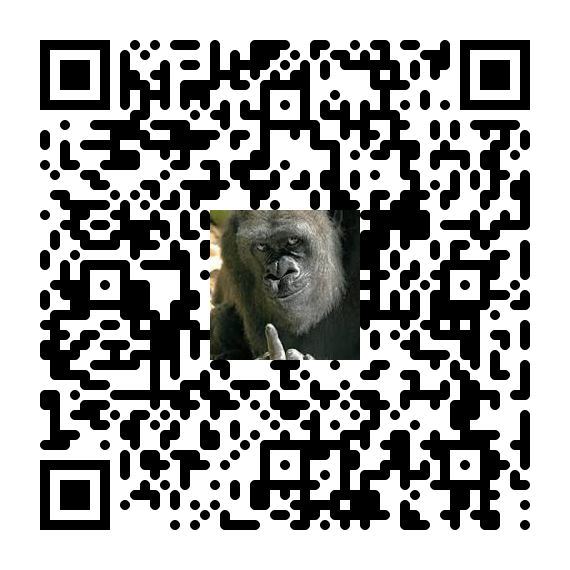

In [ ]:
from IPython.display import Image
Image('final_qr.png')